<a href="https://colab.research.google.com/github/LuGorr/NLP-Assignments/blob/main/A1/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Group members

|  Name   |  Surname   |     Email                            |    Student ID                                             |
| :-----: | :--------: | :----------------------------------: | :-----------------------------------------------------: |
| Ludovico  | Gorrieri   | `ludovico.gorrieri@studio.unibo.it`   |  0001199160 |
| Alessandro  | Capialbi | `alessandro.capialbi@studio.unibo.it`  | 0001191564 |
| Faezeh  | Sarlakifar | `faezeh.sarlakifar@studio.unibo.it`  | 0001164608 |

## Task 1 & 2

### Download the dataset

In [1]:
# !wget https://github.com/nlp-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data

In [2]:
!git clone https://github.com/nlp-unibo/nlp-course-material.git
%cd "nlp-course-material/2025-2026/Assignment 1"

fatal: destination path 'nlp-course-material' already exists and is not an empty directory.
/tf/notebooks/Uni/magistrale/NLP/NLP-Assignments/A1/nlp-course-material/2025-2026/Assignment 1


### **Tweet Preprocessing and Label Aggregation Script**

This script prepares the dataset of tweets for NLP tasks.
It handles text cleaning, tokenization, lemmatization, and label aggregation for supervised learning.
Below is a detailed explanation of each section.

#### 1. Importing Required Libraries:

    a) pandas / numpy → for data manipulation.
    b) re → regular expressions for text cleaning.
    c) nltk → for tokenization, POS tagging, and lemmatization.
    d) Counter → to count occurrences of labels and select the majority vote.

#### 2. Preparing NLTK Resources:

    This block ensures that all required NLTK corpora and models are available locally.
    If a resource is missing, it is automatically downloaded.

#### 3. Initializing Tools:

    WhitespaceTokenizer → splits text based on spaces (useful after cleaning).
    WordNetLemmatizer → reduces words to their base or dictionary form using WordNet.

#### 4. Helper Function: get_wordnet_key(pos_tag):
    This function maps Penn Treebank POS tags (e.g., NN, VB, JJ) to WordNet’s format (noun, verb, adjective, adverb).
    This step is essential because WordNetLemmatizer requires the part of speech to perform accurate lemmatization.

#### 5. Lemmatization Function: lem_text(row):
    Reduces words to their dictionary form (lemma) using POS information.
    
    This function:

    1) Tokenizes the tweet into words.
    2) Assigns POS tags using NLTK’s pos_tag.
    3) Lemmatizes each word according to its part of speech.
    4) Returns the lemmatized tweet as a single string.

#### 6. Cleaning Function: cleaner(row):

    Purpose: Remove noise and standardize text before analysis.

    Steps:

    1) lower(): Converts all text to lowercase
    2) Remove URLs: Regex https?:\/\/.\S+ removes URLs and links
    3) Remove mentions & hashtags:	Regex [@#].\S+ removes @user and #topic
    4) Remove emojis/symbols: Unicode ranges cover emoticons, flags, pictographs
    5) Remove non-alphanumeric:	Keeps only letters, digits, and spaces
    6) Normalize whitespace:	Collapses multiple spaces into one

#### 7. Label Aggregation:

    This part aggregates multiple label votes for a tweet into a single numeric label.

    How it works:

    1) For each row, it collects all values in labels_task2 except "UNKNOWN".
    2) Uses Counter to find the most common label (majority vote).
    3) Maps that label to a numerical ID using the mapping dictionary.

#### Summary

    This script prepares tweets by performing:

    1) cleaner():	Remove unwanted characters and normalize text
    2) lem_text(): Lemmatize words for consistent representation
    3) aggregator(): Convert multiple annotations into a single label

    Together, these functions create a clean, normalized, and labeled dataset,
    ideal for tasks like text classication that we will perform.


In [3]:
!pip install nltk

In [4]:
import json
import pandas as pd
import numpy as np
from collections import Counter
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.tokenize import (word_tokenize,
                            sent_tokenize,
                            WhitespaceTokenizer);

# Prepare NLTK
resources = [
    ('corpora/omw-1.4', 'omw-1.4'),
    ('corpora/wordnet', 'wordnet'),
    ('taggers/averaged_perceptron_tagger', 'averaged_perceptron_tagger'),
    ('taggers/averaged_perceptron_tagger_eng', 'averaged_perceptron_tagger_eng'),
    ('tokenizers/punkt_tab', 'punkt_tab'),
    ('tokenizers/punkt', 'punkt')
]

for resource_path, download_name in resources:
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(download_name, quiet=True)

tokenizer = WhitespaceTokenizer()
lemmatizer = WordNetLemmatizer()


def get_wordnet_key(pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return 'n'

# Lemmatize a row's tweet
def lem_text(row):
    tokens = tokenizer.tokenize(row.tweet)
    tagged = pos_tag(tokens)
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag))
             for word, tag in tagged]
    return " ".join(words)

# Normalization: clean a row's tweet
def cleaner(row):
    text = row.tweet
    text = text.lower()
    text = re.sub(r'https?:\/\/.\S+', '', text)
    text = re.sub(r'[@#].\S+', '', text)
    text = re.sub(
        "["
            u"\U0001F600-\U0001F64F"  # Emoticons
            u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # Transport & map symbols
            u"\U0001F1E0-\U0001F1FF"  # Flags
                                    "]+", '', text
    )
    text = re.sub(r'[^a-z^0-9^\s]*', '', text)
    text = ' '.join(text.split())
    return text

# Aggregate the labels (labels_task2)
aggregator = lambda row: \
    mapping[Counter([vote for vote in row.labels_task2 if vote != "UNKNOWN"]).most_common(1)[0][0]]

mapping = {
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}

### Clean, split and lemmatize the dataset.

In [5]:
# Load the files
with open("data/training.json", "r") as tr, \
     open("data/validation.json", "r") as te, \
     open("data/test.json", "r") as va:
    train_json = json.load(tr)
    val_json = json.load(te)
    test_json = json.load(va)

# Create the dataframes (setting the index to id_EXIST)
dts = {
    "train": pd.DataFrame.from_dict(train_json, orient="index").set_index("id_EXIST"),
    "test": pd.DataFrame.from_dict(test_json, orient="index").set_index("id_EXIST"),
    "val": pd.DataFrame.from_dict(val_json, orient="index").set_index("id_EXIST")
}

# Unnecessary columns
drop_cols = ["number_annotators", "annotators", "gender_annotators",
    "age_annotators", "labels_task1", "labels_task3", "split", "lang"]

# Clean and lemmatize the data
for name, df in dts.items():
    df = df[df.lang == "en"].copy() # Drop spanish.

    df = df.drop(columns=drop_cols) # Drop unnecessary cols.

    df["labels"] = df.apply(aggregator, axis=1) # Aggregate the labels (maj. voting).
    df = df.drop(columns="labels_task2")

    for func in [cleaner, lem_text]:
        df["tweet"] = df.apply(func, axis=1) # Clean the tweets.

    dts[name] = df

train, test, val = dts.values()

train.rename(columns={"labels": "label"}, inplace=True)
train.rename(columns={"tweet": "text"}, inplace=True)
val.rename(columns={"labels": "label"}, inplace=True)
val.rename(columns={"tweet": "text"}, inplace=True)
test.rename(columns={"labels": "label"}, inplace=True)
test.rename(columns={"tweet": "text"}, inplace=True)

In [6]:
train.head()

,text,label
id_EXIST,,
200001,ffs how about lay the blame on the bastard who...,0
200002,write a uni essay in my local pub with a coffe...,3
200003,it be 2021 not 1921 i dont appreciate that on ...,3
200004,this be unacceptable use her title a you do fo...,0
200005,make yourself a hard target basically boil dow...,0


## Task 3: Text Encoding

### Setup

In [7]:
!pip install gensim

In [8]:
import os
import tensorflow as tf
tf_data = tf.data
import keras
from keras import layers

import gensim
import gensim.downloader as gloader
from gensim.models import KeyedVectors

import numpy as np

2025-12-21 16:27:49.819920: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [9]:
os.environ["KERAS_BACKEND"] = "tensorflow"

### Build the vocabulary

In [10]:
label_map = {0: "NOT SEXIST", 1: "DIRECT", 2: "JUDGEMENTAL", 3: "REPORTED"}

label_counts = [train.label[train.label == i].count() for i in label_map.keys()]
print(label_counts)
majority = np.argmax(label_counts)
for i in label_map:
  if i != majority:
    for _ in range(label_counts[majority] - label_counts[i]):
      train = pd.concat([pd.DataFrame(train[train.label == i].sample(1), \
                          columns=train.columns), train], ignore_index=True)

print([train.label[train.label == i].count() for i in label_map.keys()])

[2151, 641, 208, 260]
[2151, 2151, 2151, 2151]


In [11]:
from random import shuffle

train = train.sample(frac=1).reset_index(drop=True)
#shuffle(train_new)


In [12]:
vectorizer = layers.TextVectorization(max_tokens=20000)
vectorizer.adapt(train["text"])

I0000 00:00:1766334473.924849   13094 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15480 MB memory:  -> device: 0, name: AMD Radeon RX 7800 XT, pci bus id: 0000:2d:00.0


In [13]:
# Create a TensorFlow Dataset for training data
# Each batch contains 64 examples for efficient training
train_ds = tf.data.Dataset.from_tensor_slices((train["text"], train["label"])) \
    .map(lambda x, y: (vectorizer(x), y)) \
    .padded_batch(32) \
    .prefetch(tf.data.AUTOTUNE)

# Create a TensorFlow Dataset for validation data
valid_ds = tf.data.Dataset.from_tensor_slices((val["text"], val["label"])) \
    .map(lambda x, y: (vectorizer(x), y)) \
    .padded_batch(32) \
    .prefetch(tf.data.AUTOTUNE)
# Create a TensorFlow Dataset for test data
test_ds = tf.data.Dataset.from_tensor_slices((test["text"], test["label"])) \
    .map(lambda x, y: (vectorizer(x), y))


In [14]:
vocab = vectorizer.get_vocabulary()
print(vocab[:10])

['', '[UNK]', 'be', 'the', 'a', 'to', 'and', 'woman', 'of', 'i']


The vectorizer has its vocabulary frozen after adapt().

When we apply it to the val or test set,

any word not seen during training will automatically be replaced with the OOV token (default **UNK**, index 1).

We do not need to manually preprocess or map OOV tokens, TensorFlow will handle it internally.

### Use GloVe Embedding vectors

#### Convert GloVe format to Word2Vec format

In [15]:


import os
import sys

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    glove_dst = "/content/drive/MyDrive/glove.twitter.27B.50d.txt"
else:
    glove_dst = "glove.twitter.27B.50d.txt"
glove_src = "glove.twitter.27B.50d.txt"

if os.path.exists(glove_dst):
    print("GloVe file already exists in Drive.")
else:
    print("Downloading GloVe file...")
    !wget http://nlp.stanford.edu/data/glove.twitter.27B.zip
    !unzip -q glove.twitter.27B.zip
    print("Copying GloVe file...")
    !cp "$glove_src" "$glove_dst"
    print("File copied successfully!")

glove_file = glove_dst

GloVe file already exists in Drive.


In [16]:
# Load GloVe into Gensim
twitter_glove = KeyedVectors.load_word2vec_format(glove_file, binary=False, no_header=True)

print(f"Loaded Twitter GloVe with {len(twitter_glove.key_to_index):,} tokens")

Loaded Twitter GloVe with 1,193,514 tokens


#### Build TensorFlow embedding matrix

In [17]:
vocab = vectorizer.get_vocabulary()
embedding_dim = twitter_glove.vector_size
embedding_matrix = np.zeros((len(vocab), embedding_dim))

### OOV handling

#### Random embedding initialization for OOV words

Then we will learn them by training

## Task 4 & 5

In [18]:
# Construct the embedding matrix using GloVe vectors or random initialization
# For each word in the vocabulary:
# - If the word exists in the pre-trained GloVe embeddings, use its vector.
# - Otherwise, initialize its vector with random values drawn from a normal distribution
#   (mean = 0, std = 0.6) to represent out-of-vocabulary (OOV) words.
count_0 = 0
count_1 = 0
for i, word in enumerate(vocab):
    if word in twitter_glove:
        embedding_matrix[i] = twitter_glove[word]
        count_0 += 1
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))
        count_1 += 1
print(count_0)
print(count_1)

8446
2123


In [19]:
train

,text,label
0,fight for it do you advise your bos richard sh...,0
1,someone must have a penis envy,2
2,afghan woman cannot be part of any sport inclu...,2
3,it be 2021 not 1921 i dont appreciate that on ...,3
4,i agree i wish i could be brave to take off hi...,3
...,...,...
8599,many men and woman of this generation have a f...,2
8600,be it not a compliment it never okay,3
8601,im hop netflix us jerry a a way to shine light...,3
8602,movie of the day organize isler 2005 imdb 74a ...,0



Training baseline model with seed 42...
Epoch 1/30


2025-12-21 16:28:38.820745: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a0ee800a100 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
2025-12-21 16:28:38.820762: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): AMD Radeon RX 7800 XT, AMDGPU ISA version: gfx1101
2025-12-21 16:28:38.866620: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-21 16:28:39.314624: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-21 16:28:39.314642: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of

 1/32 ━━━━━━━━━━━━━━━━━━━━ 3:05 6s/step - accuracy: 0.2500 - loss: 1.9083 - macro_f1_score: 0.2699

I0000 00:00:1766334522.869082   13196 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.2539 - loss: 1.8440 - macro_f1_score: 0.2503 - val_accuracy: 0.5650 - val_loss: 1.4974 - val_macro_f1_score: 0.2597 - learning_rate: 0.0010
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 218ms/step - accuracy: 0.2539 - loss: 1.6282 - macro_f1_score: 0.2532 - val_accuracy: 0.5085 - val_loss: 1.5075 - val_macro_f1_score: 0.2568 - learning_rate: 0.0010
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.2793 - loss: 1.5730 - macro_f1_score: 0.2769 - val_accuracy: 0.5763 - val_loss: 1.4958 - val_macro_f1_score: 0.2561 - learning_rate: 0.0010
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - accuracy: 0.2656 - loss: 1.5681 - macro_f1_score: 0.2620 - val_accuracy: 0.5706 - val_loss: 1.4911 - val_macro_f1_score: 0.2353 - learning_rate: 0.0010
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2842 - loss: 1.5414 - macro_f1_score: 0.2828 - val_accuracy: 0.4915 - val_loss: 1.5009 - val_macro_f1_score: 0.2405 - learni

2025-12-21 16:29:46.552061: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 245ms/step - accuracy: 0.2694 - loss: 1.5054 - macro_f1_score: 0.2666 - val_accuracy: 0.4011 - val_loss: 1.4934 - val_macro_f1_score: 0.2537 - learning_rate: 5.0000e-04
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.


/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.68      0.80      0.73       120
      DIRECT       0.00      0.00      0.00        28
 JUDGEMENTAL       0.00      0.00      0.00        14
    REPORTED       0.15      0.33      0.21        15

    accuracy                           0.57       177
   macro avg       0.21      0.28      0.24       177
weighted avg       0.47      0.57      0.51       177

---------------------------------

Plotting Confusion Matrix...


2025-12-21 16:29:53.523860: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


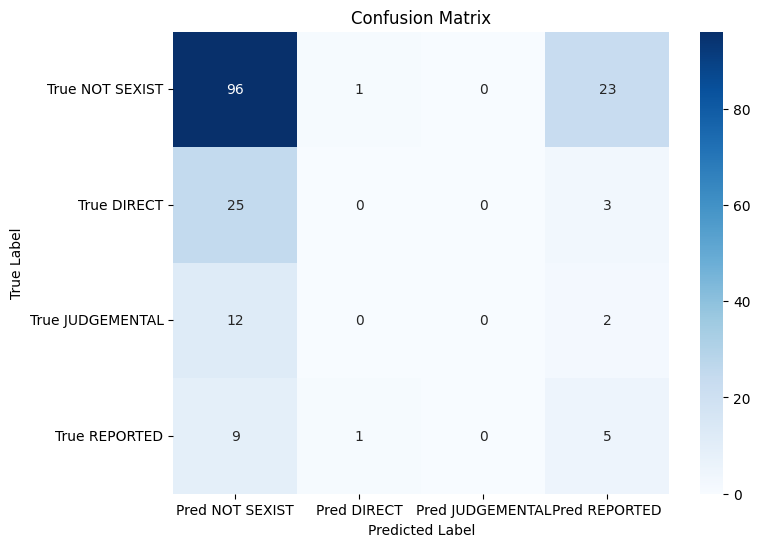


Training stacked model with seed 42...
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.2373 - loss: 1.7567 - macro_f1_score: 0.2337 - val_accuracy: 0.0847 - val_loss: 1.6970 - val_macro_f1_score: 0.0432 - learning_rate: 0.0010
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 297ms/step - accuracy: 0.2471 - loss: 1.6626 - macro_f1_score: 0.2458 - val_accuracy: 0.0904 - val_loss: 1.6596 - val_macro_f1_score: 0.0436 - learning_rate: 0.0010
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.2744 - loss: 1.6329 - macro_f1_score: 0.2735 - val_accuracy: 0.0904 - val_loss: 1.6182 - val_macro_f1_score: 0.0561 - learning_rate: 0.0010
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 298ms/step - accuracy: 0.2402 - loss: 1.6050 - macro_f1_score: 0.2355 - val_accuracy: 0.0904 - val_loss: 1.5870 - val_macro_f1_score: 0.0434 - learning_rate: 0.0010
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2412 - loss: 1.5783 - macro_f1_score: 0.2379 - val_accuracy: 0.0847 - val

/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2598 - loss: 1.5026 - macro_f1_score: 0.2551 - val_accuracy: 0.0904 - val_loss: 1.5160 - val_macro_f1_score: 0.0928 - learning_rate: 0.0010
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2803 - loss: 1.4935 - macro_f1_score: 0.2799 - val_accuracy: 0.1638 - val_loss: 1.4963 - val_macro_f1_score: 0.1749 - learning_rate: 0.0010
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.2852 - loss: 1.4794 - macro_f1_score: 0.2844 - val_accuracy: 0.3955 - val_loss: 1.4739 - val_macro_f1_score: 0.2323 - learning_rate: 0.0010
Epoch 13/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3125 - loss: 1.4636 - macro_f1_score: 0.3066 - val_accuracy: 0.2881 - val_loss: 1.4691 - val_macro_f1_score: 0.2309 - learning_rate: 0.0010
Epoch 14/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3262 - loss: 1.4514 - macro_f1_score: 0.3254 - val_accuracy: 0.1525 - val_loss: 1.4710 - val_macro_f1_score: 0.1878 - lear

2025-12-21 16:31:57.766496: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


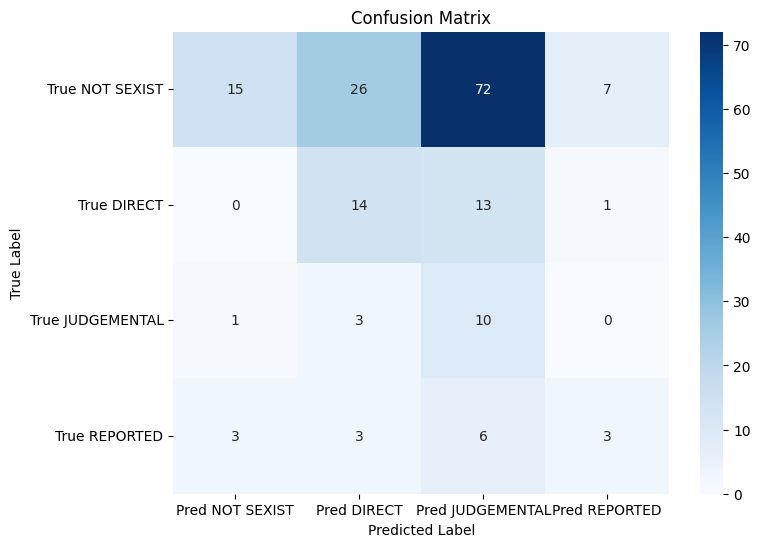


Training baseline model with seed 123...
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.2539 - loss: 1.8776 - macro_f1_score: 0.2498 - val_accuracy: 0.1864 - val_loss: 1.5957 - val_macro_f1_score: 0.1312 - learning_rate: 0.0010
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 218ms/step - accuracy: 0.2432 - loss: 1.6747 - macro_f1_score: 0.2429 - val_accuracy: 0.2825 - val_loss: 1.5345 - val_macro_f1_score: 0.1598 - learning_rate: 0.0010
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.2695 - loss: 1.6079 - macro_f1_score: 0.2694 - val_accuracy: 0.4294 - val_loss: 1.5083 - val_macro_f1_score: 0.2176 - learning_rate: 0.0010
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - accuracy: 0.2676 - loss: 1.5711 - macro_f1_score: 0.2679 - val_accuracy: 0.4576 - val_loss: 1.5022 - val_macro_f1_score: 0.2218 - learning_rate: 0.0010
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2510 - loss: 1.5608 - macro_f1_score: 0.2493 - val_accuracy: 0.2712 - v

/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2822 - loss: 1.5014 - macro_f1_score: 0.2739 - val_accuracy: 0.2881 - val_loss: 1.4830 - val_macro_f1_score: 0.2012 - learning_rate: 0.0010
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2881 - loss: 1.4925 - macro_f1_score: 0.2822 - val_accuracy: 0.4859 - val_loss: 1.4595 - val_macro_f1_score: 0.2740 - learning_rate: 0.0010
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3057 - loss: 1.4822 - macro_f1_score: 0.2963 - val_accuracy: 0.5537 - val_loss: 1.4223 - val_macro_f1_score: 0.2730 - learning_rate: 0.0010
Epoch 13/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2910 - loss: 1.4716 - macro_f1_score: 0.2851 - val_accuracy: 0.4689 - val_loss: 1.4462 - val_macro_f1_score: 0.2977 - learning_rate: 0.0010
Epoch 14/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3066 - loss: 1.4684 - macro_f1_score: 0.3021 - val_accuracy: 0.4124 - val_loss: 1.4412 - val_macro_f1_score: 0.2533 - lear

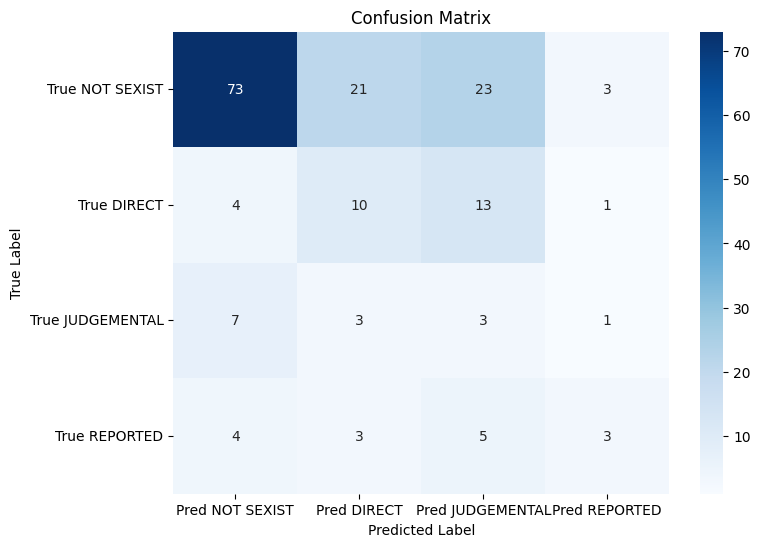


Training stacked model with seed 123...
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.2432 - loss: 1.8011 - macro_f1_score: 0.2415 - val_accuracy: 0.2655 - val_loss: 1.6734 - val_macro_f1_score: 0.1987 - learning_rate: 0.0010
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 296ms/step - accuracy: 0.2666 - loss: 1.6673 - macro_f1_score: 0.2664 - val_accuracy: 0.3559 - val_loss: 1.6353 - val_macro_f1_score: 0.2053 - learning_rate: 0.0010
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.2412 - loss: 1.6433 - macro_f1_score: 0.2417 - val_accuracy: 0.5593 - val_loss: 1.6010 - val_macro_f1_score: 0.2514 - learning_rate: 0.0010
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 298ms/step - accuracy: 0.2666 - loss: 1.6071 - macro_f1_score: 0.2633 - val_accuracy: 0.5424 - val_loss: 1.5809 - val_macro_f1_score: 0.2519 - learning_rate: 0.0010
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2227 - loss: 1.5921 - macro_f1_score: 0.2226 - val_accuracy: 0.2712 - va

/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.2607 - loss: 1.5154 - macro_f1_score: 0.2546 - val_accuracy: 0.1017 - val_loss: 1.5319 - val_macro_f1_score: 0.0784 - learning_rate: 0.0010
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2793 - loss: 1.5062 - macro_f1_score: 0.2786 - val_accuracy: 0.6497 - val_loss: 1.4899 - val_macro_f1_score: 0.3354 - learning_rate: 0.0010
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2588 - loss: 1.4988 - macro_f1_score: 0.2542 - val_accuracy: 0.6441 - val_loss: 1.4793 - val_macro_f1_score: 0.3022 - learning_rate: 0.0010
Epoch 13/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.2783 - loss: 1.4851 - macro_f1_score: 0.2779 - val_accuracy: 0.3277 - val_loss: 1.4889 - val_macro_f1_score: 0.2014 - learning_rate: 0.0010
Epoch 14/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.2773 - loss: 1.4686 - macro_f1_score: 0.2727 - val_accuracy: 0.4633 - val_loss: 1.4609 - val_macro_f1_score: 0.3547 - lear

2025-12-21 16:35:19.316361: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


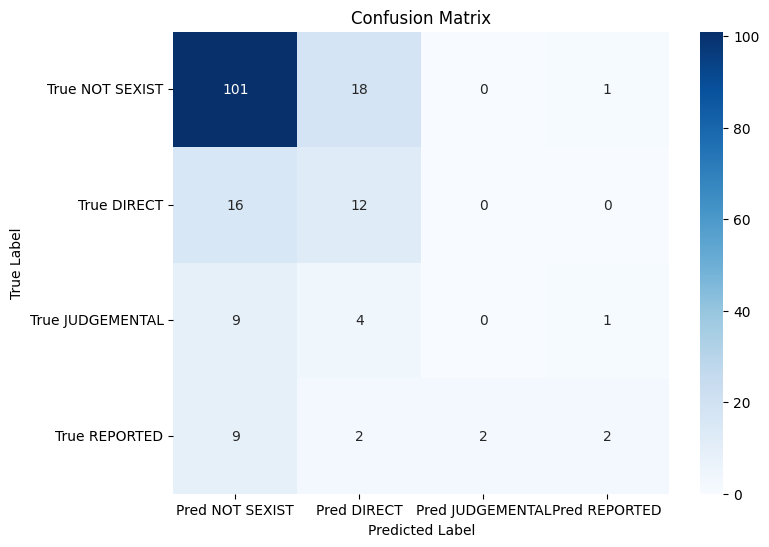


Training baseline model with seed 999...
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.2432 - loss: 1.8415 - macro_f1_score: 0.2427 - val_accuracy: 0.1073 - val_loss: 1.6172 - val_macro_f1_score: 0.0872 - learning_rate: 0.0010
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.2363 - loss: 1.6439 - macro_f1_score: 0.2361 - val_accuracy: 0.1073 - val_loss: 1.5784 - val_macro_f1_score: 0.0869 - learning_rate: 0.0010
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.2461 - loss: 1.5809 - macro_f1_score: 0.2455 - val_accuracy: 0.1243 - val_loss: 1.5555 - val_macro_f1_score: 0.0981 - learning_rate: 0.0010
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.2988 - loss: 1.5419 - macro_f1_score: 0.2982 - val_accuracy: 0.1356 - val_loss: 1.5338 - val_macro_f1_score: 0.1076 - learning_rate: 0.0010
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2441 - loss: 1.5387 - macro_f1_score: 0.2441 - val_accuracy: 0.1469 - v

/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2754 - loss: 1.4900 - macro_f1_score: 0.2670 - val_accuracy: 0.2203 - val_loss: 1.4933 - val_macro_f1_score: 0.1808 - learning_rate: 0.0010
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3262 - loss: 1.4604 - macro_f1_score: 0.3174 - val_accuracy: 0.2994 - val_loss: 1.4660 - val_macro_f1_score: 0.2177 - learning_rate: 0.0010
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3203 - loss: 1.4566 - macro_f1_score: 0.3127 - val_accuracy: 0.4068 - val_loss: 1.4568 - val_macro_f1_score: 0.2921 - learning_rate: 0.0010
Epoch 13/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3457 - loss: 1.4411 - macro_f1_score: 0.3458 - val_accuracy: 0.4181 - val_loss: 1.4500 - val_macro_f1_score: 0.3196 - learning_rate: 0.0010
Epoch 14/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3418 - loss: 1.4369 - macro_f1_score: 0.3414 - val_accuracy: 0.4237 - val_loss: 1.4322 - val_macro_f1_score: 0.3015 - lear

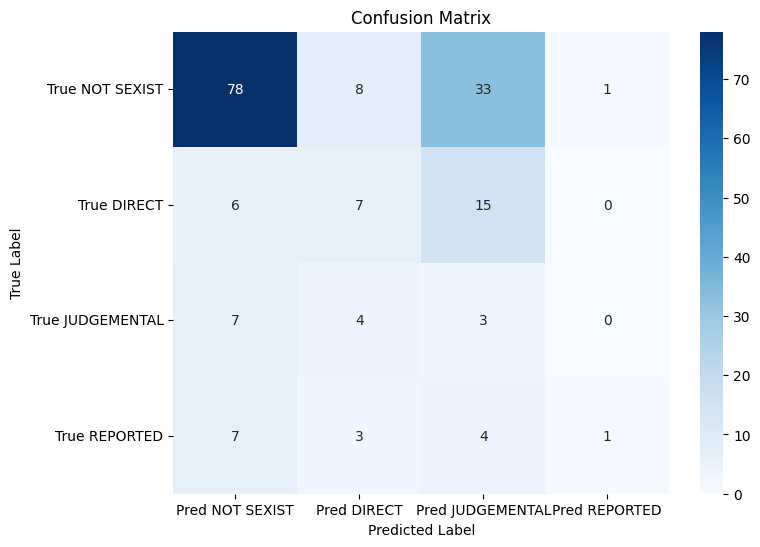


Training stacked model with seed 999...
Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.2686 - loss: 1.7772 - macro_f1_score: 0.2674 - val_accuracy: 0.1017 - val_loss: 1.6872 - val_macro_f1_score: 0.1062 - learning_rate: 0.0010
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 295ms/step - accuracy: 0.2637 - loss: 1.6680 - macro_f1_score: 0.2606 - val_accuracy: 0.1525 - val_loss: 1.6366 - val_macro_f1_score: 0.0701 - learning_rate: 0.0010
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.2617 - loss: 1.6287 - macro_f1_score: 0.2598 - val_accuracy: 0.1977 - val_loss: 1.6078 - val_macro_f1_score: 0.1751 - learning_rate: 0.0010
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 257ms/step - accuracy: 0.2715 - loss: 1.5822 - macro_f1_score: 0.2695 - val_accuracy: 0.1864 - val_loss: 1.5712 - val_macro_f1_score: 0.1830 - learning_rate: 0.0010
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2676 - loss: 1.5720 - macro_f1_score: 0.2665 - val_accuracy: 0.1412 - va

/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.2627 - loss: 1.5013 - macro_f1_score: 0.2518 - val_accuracy: 0.1017 - val_loss: 1.5147 - val_macro_f1_score: 0.0907 - learning_rate: 0.0010
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.2832 - loss: 1.4942 - macro_f1_score: 0.2692 - val_accuracy: 0.1808 - val_loss: 1.5017 - val_macro_f1_score: 0.1654 - learning_rate: 0.0010
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3047 - loss: 1.4746 - macro_f1_score: 0.2829 - val_accuracy: 0.2090 - val_loss: 1.4770 - val_macro_f1_score: 0.1875 - learning_rate: 0.0010
Epoch 13/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3232 - loss: 1.4611 - macro_f1_score: 0.3019 - val_accuracy: 0.1977 - val_loss: 1.4654 - val_macro_f1_score: 0.1605 - learning_rate: 0.0010
Epoch 14/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3330 - loss: 1.4470 - macro_f1_score: 0.3038 - val_accuracy: 0.1469 - val_loss: 1.4770 - val_macro_f1_score: 0.1467 - lear

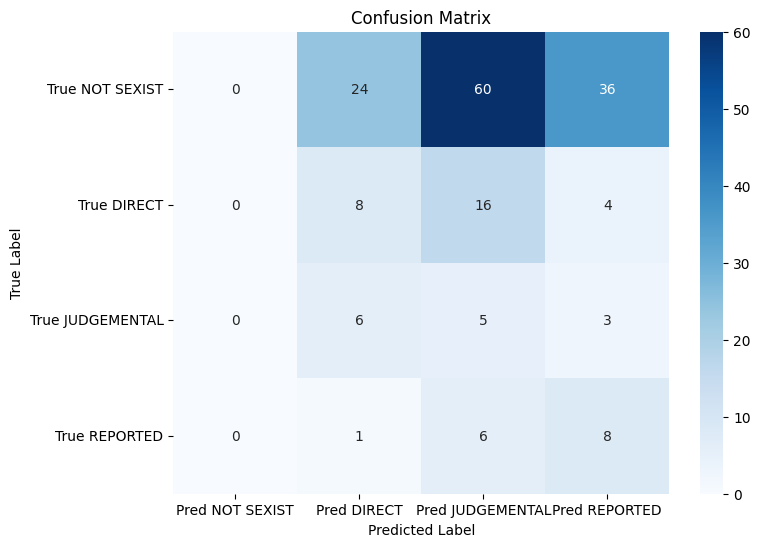


Retraining best base model with seed 123...


/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 22.

--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.82      0.66      0.73       120
      DIRECT       0.30      0.39      0.34        28
 JUDGEMENTAL       0.08      0.21      0.12        14
    REPORTED       0.29      0.13      0.18        15

    accuracy                           0.54       177
   macro avg       0.37      0.35      0.34       177
weighted avg       0.64      0.54      0.57       177

---------------------------------

Plotting Confusion Matrix...


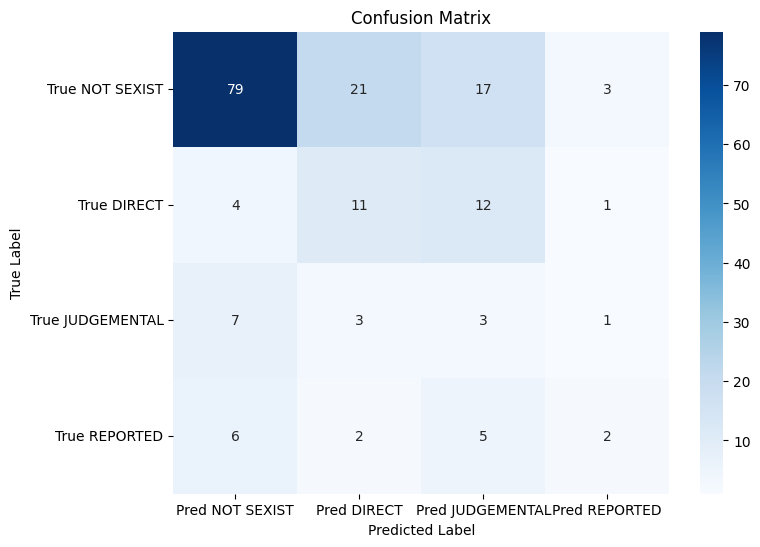

Best model saved as 'best_base_model.keras'

Retraining best stacked model with seed 123...


/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 21.

--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.83      0.57      0.68       120
      DIRECT       0.24      0.43      0.31        28
 JUDGEMENTAL       0.12      0.21      0.16        14
    REPORTED       0.29      0.40      0.33        15

    accuracy                           0.51       177
   macro avg       0.37      0.40      0.37       177
weighted avg       0.64      0.51      0.55       177

---------------------------------

Plotting Confusion Matrix...


2025-12-21 16:41:48.418139: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


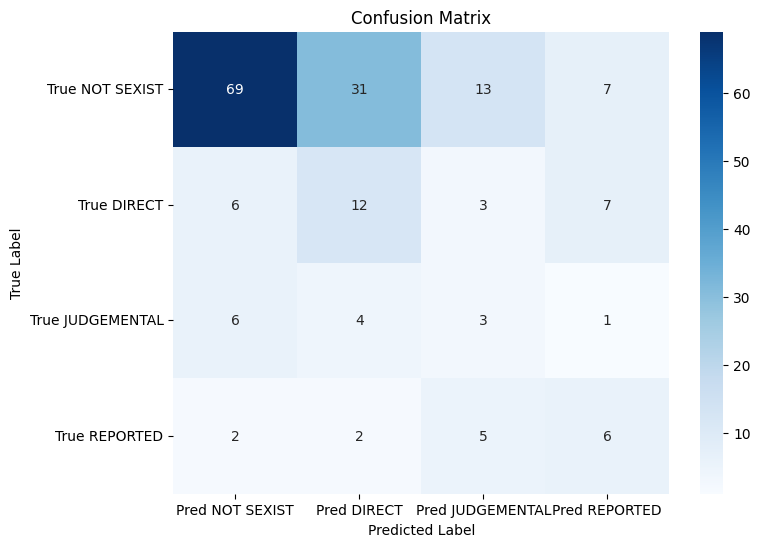

Best model saved as 'best_stacked_model.keras'


In [20]:
from matplotlib import pyplot as plt
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix)
from tensorflow.keras.callbacks import ReduceLROnPlateau, Callback
from itertools import product
import gc
from tensorflow.keras import backend as K


import tensorflow as tf
from tensorflow.keras.callbacks import Callback
import numpy as np
import seaborn as sns
        
# Custom Keras Metric for Macro F1-Score
class MacroF1(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='macro_f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.false_positives = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        # Reshape y_true and y_pred to (batch_size, 1) for broadcasting
        y_true_reshaped = tf.expand_dims(y_true, axis=-1)
        y_pred_reshaped = tf.expand_dims(y_pred, axis=-1)

        # Create class_range tensor (e.g., [0, 1, 2, 3])
        class_range = tf.range(self.num_classes, dtype=tf.int32)

        # Compare true labels with each class. Result: (batch_size, num_classes)
        true_class_masks = tf.equal(y_true_reshaped, class_range)
        # Compare predicted labels with each class. Result: (batch_size, num_classes)
        pred_class_masks = tf.equal(y_pred_reshaped, class_range)

        # Calculate True Positives (y_true == c AND y_pred == c) for all classes
        tp_batch = tf.reduce_sum(tf.cast(tf.logical_and(true_class_masks, pred_class_masks), tf.float32), axis=0)
        # Calculate False Positives (y_true != c AND y_pred == c) for all classes
        fp_batch = tf.reduce_sum(tf.cast(tf.logical_and(tf.logical_not(true_class_masks), pred_class_masks), tf.float32), axis=0)
        # Calculate False Negatives (y_true == c AND y_pred != c) for all classes
        fn_batch = tf.reduce_sum(tf.cast(tf.logical_and(true_class_masks, tf.logical_not(pred_class_masks)), tf.float32), axis=0)

        self.true_positives.assign_add(tp_batch)
        self.false_positives.assign_add(fp_batch)
        self.false_negatives.assign_add(fn_batch)

    def result(self):
        precision = self.true_positives / (self.true_positives + self.false_positives + tf.keras.backend.epsilon())
        recall = self.true_positives / (self.true_positives + self.false_negatives + tf.keras.backend.epsilon())
        f1_scores = 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())
        return tf.reduce_mean(f1_scores)

    def reset_state(self):
        self.true_positives.assign(np.zeros((self.num_classes,)))
        self.false_positives.assign(np.zeros((self.num_classes,)))
        self.false_negatives.assign(np.zeros((self.num_classes,)))

# Hyperparameters
LSTM_UNITS = 25
DROPOUT_RATE = 0.7
LR = 1e-3
EPOCHS = 30
SEEDS = [42, 123, 999]
L2_FACTOR = 1e-3
classes = [0, 1, 2, 3]

def get_callbacks():
    return [ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.5,
      patience=3,
      min_lr=1e-6,
      verbose=1
  ), tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # Monitor the custom F1 score
    mode='min',
    patience=5,
    restore_best_weights=True,
    verbose=1
    )]
# Build model
def build_model(stacked=False, lr=LR):
    model = models.Sequential([
        layers.Embedding(
            input_dim=len(vocab),
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            mask_zero=True,
            trainable=True,
            name='encoder-embedding'
        ),
        layers.Bidirectional(
            layers.LSTM(LSTM_UNITS,
                        return_sequences=stacked,
                        kernel_regularizer=regularizers.l2(L2_FACTOR),
                        activation='leaky_relu', # <--- CAMBIA QUI: Forza l'uscita dal kernel monolitico
                        recurrent_activation='sigmoid'
                       )
        ),
        #layers.LayerNormalization(),
        layers.Dropout(DROPOUT_RATE),
        layers.Bidirectional(
            layers.LSTM(LSTM_UNITS,
                        return_sequences=False,
                        kernel_regularizer=regularizers.l2(L2_FACTOR),
                        activation='leaky_relu', # <--- CAMBIA QUI: Forza l'uscita dal kernel monolitico
                        recurrent_activation='sigmoid'
                        )
                       ) if stacked else layers.Identity(),
        #layers.LayerNormalization() if stacked else layers.Identity(),
        layers.Dropout(DROPOUT_RATE) if stacked else layers.Identity(),
        # Add a Dense layer
        layers.Dense(
            64,
            activation = "leaky_relu",
            kernel_regularizer=regularizers.l2(L2_FACTOR)
        ),
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(4, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        #loss=FocalLoss(gamma = 2.0, alpha = alpha),
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipvalue=1.0),
        metrics=['accuracy', MacroF1(num_classes=len(classes))]
    )
    return model

# Evaluation helper
#@tf.function(reduce_retracing=True)
def predict_batch(model, x):
    return model(x, training=False)

def evaluate_model(model, valid_ds, class_names=['NOT SEXIST', 'DIRECT', 'JUDGEMENTAL', 'REPORTED']):
    """
    Compute macro F1, precision, recall, and display classification report
    and confusion matrix on the validation set.
    """
    y_true = []
    y_pred_probs = []

    # Iterate over the validation dataset
    for x_batch, y_batch in valid_ds:
        # Get model predictions (probabilities) using the tf.function
        preds = predict_batch(model, x_batch)

        # Store true labels (ground truth)
        y_true.extend(y_batch.numpy())
        # Store predicted probabilities
        y_pred_probs.extend(preds.numpy())

    # Get the predicted class index (the one with the highest probability)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 1. Print the detailed Classification Report
    # This shows precision, recall, f1-score for each class
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print("---------------------------------")

    # 2. Compute and display the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    print("\nPlotting Confusion Matrix...")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Pred {name}' for name in class_names],
                yticklabels=[f'True {name}' for name in class_names])
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Calculate macro-averaged metrics
    # 'macro' calculates metrics for each label, and finds their unweighted mean.
    # This is crucial for imbalanced datasets.
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)

    return f1, prec, rec

# Early stopping callback (prevents overfitting)

# Main training loop
f1_scores_base, precisions_base, recalls_base = [], [], []
f1_scores_stacked, precisions_stacked, recalls_stacked = [], [], []

for seed, stacked in list(product(SEEDS, [False, True])):
    print(f"\nTraining {"stacked" if stacked else "baseline"} model with seed {seed}...")
    tf.keras.utils.set_random_seed(seed)
    lrs = [1e-3, 1e-3]
    model = build_model(stacked, lrs[stacked])
    
    model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS,
        steps_per_epoch=32,
        callbacks=get_callbacks(),
        verbose=1
    )
    f1, prec, rec = evaluate_model(model, valid_ds)
    del model
    if 'best_model' in locals(): del best_model
    K.clear_session()
    gc.collect()
    f1_scores_stacked.append(f1) if stacked else f1_scores_base.append(f1)
    precisions_stacked.append(prec) if stacked else precisions_base.append(prec)
    recalls_stacked.append(rec) if stacked else recalls_base.append(rec)

history_best = []
for stacked in [False, True]:
    # Train and save best model
    best_seed = SEEDS[np.argmax(f1_scores_stacked if stacked else f1_scores_base)]
    print(f"\nRetraining best {"stacked" if stacked else "base"} model with seed {best_seed}...")
    tf.keras.utils.set_random_seed(best_seed)
    best_model = build_model(stacked)
    history = best_model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS,
        steps_per_epoch=32,
        callbacks=get_callbacks(), # This line previously caused a nested list issue if lr_scheduler was itself a list of callbacks
        verbose=0

    )
    history_best.append(history.history)
    evaluation = evaluate_model(best_model, valid_ds)
    best_model.save(f"best_{"stacked" if stacked else "base"}_model.keras")
    del best_model
    del history
    if 'best_model' in locals(): del best_model
    K.clear_session()
    gc.collect()
    print(f"Best model saved as 'best_{"stacked" if stacked else "base"}_model.keras'")

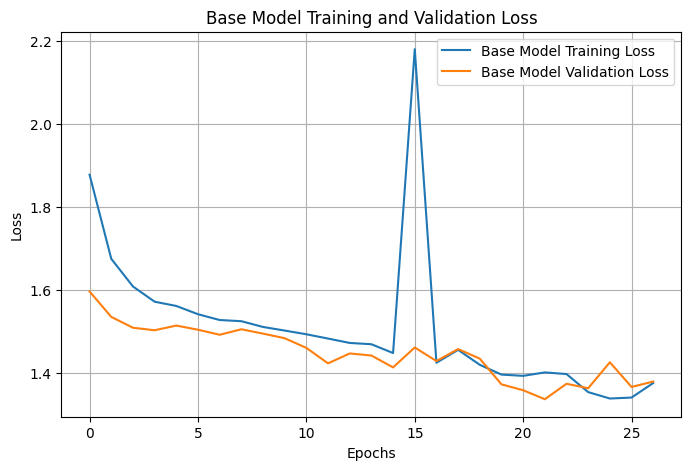

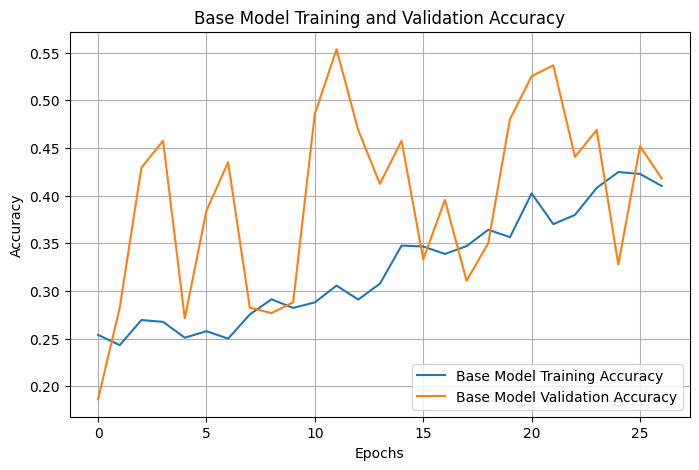

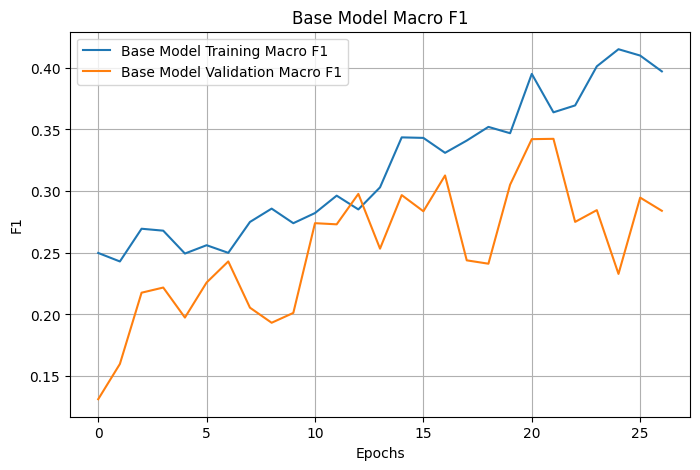

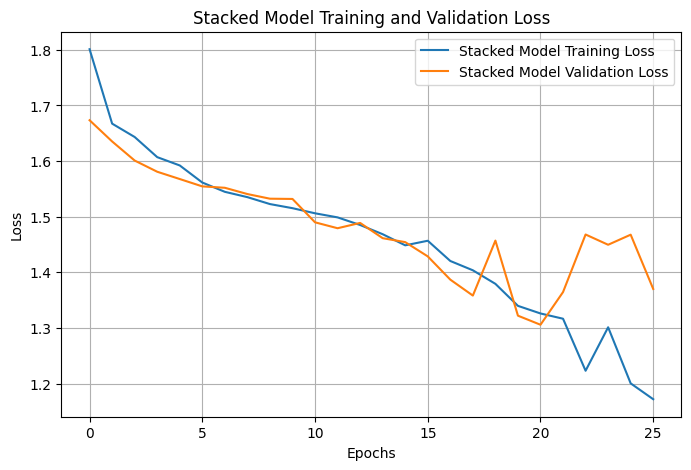

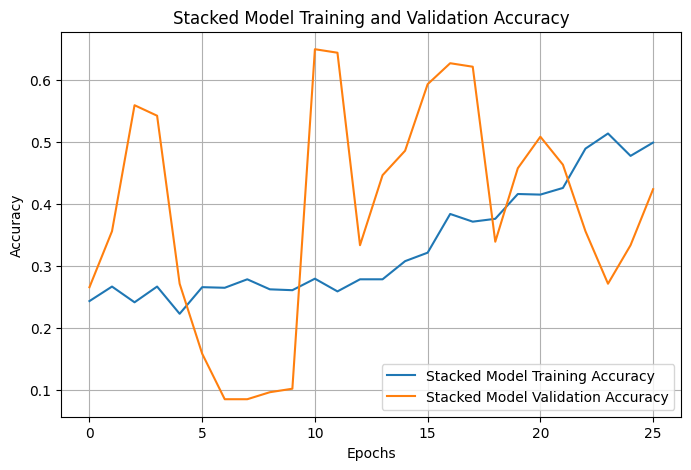

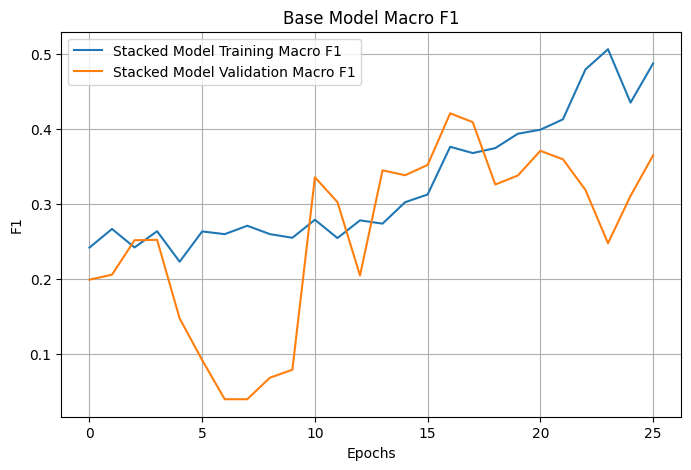

In [21]:
#Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_best[0]['loss'], label='Base Model Training Loss')
plt.plot(history_best[0]['val_loss'], label='Base Model Validation Loss')
plt.title('Base Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Plot accuracy as well
plt.figure(figsize=(8, 5))
plt.plot(history_best[0]['accuracy'], label='Base Model Training Accuracy')
plt.plot(history_best[0]['val_accuracy'], label='Base Model Validation Accuracy')
plt.title('Base Model Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[0]['macro_f1_score'], label='Base Model Training Macro F1')
plt.plot(history_best[0]['val_macro_f1_score'], label='Base Model Validation Macro F1')
plt.title('Base Model Macro F1')
plt.xlabel('Epochs')
plt.ylabel('F1')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_best[1]['loss'], label='Stacked Model Training Loss')
plt.plot(history_best[1]['val_loss'], label='Stacked Model Validation Loss')
plt.title('Stacked Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Plot accuracy as well
plt.figure(figsize=(8, 5))
plt.plot(history_best[1]['accuracy'], label='Stacked Model Training Accuracy')
plt.plot(history_best[1]['val_accuracy'], label='Stacked Model Validation Accuracy')
plt.title('Stacked Model Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[1]['macro_f1_score'], label='Stacked Model Training Macro F1')
plt.plot(history_best[1]['val_macro_f1_score'], label='Stacked Model Validation Macro F1')
plt.title('Base Model Macro F1')
plt.xlabel('Epochs')
plt.ylabel('F1')
plt.legend()
plt.grid(True)
plt.show()


### Some minor changes:

In [ ]:
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix)
from tensorflow.keras.callbacks import ReduceLROnPlateau, Callback
from itertools import product
import tensorflow as tf # Ensure tensorflow is imported


import tensorflow as tf
from tensorflow.keras.callbacks import Callback
import numpy as np

class WarmUpDecayCallback(Callback):
    """
    Callback per warm-up e decay del learning rate.
    Compatibile con tutti i tipi di variabili in Keras 3.x
    """
    def __init__(self, target_lr, total_steps, warmup_steps, end_lr=0.0001, power=1.0):
        super(WarmUpDecayCallback, self).__init__()
        self.target_lr = target_lr
        self.total_steps = total_steps
        self.warmup_steps = warmup_steps
        self.end_lr = end_lr
        self.power = power
        self.start_lr = target_lr / 100.0 if target_lr > 0 else 0.00001
        self.warmup_rate = (self.target_lr - self.start_lr) / self.warmup_steps
        self.decay_steps = float(self.total_steps - self.warmup_steps)
        self.current_step = 0

    def on_train_begin(self, logs=None):
        # Verifica e imposta il learning rate iniziale
        optimizer = self.model.optimizer

        # Se il learning_rate è una stringa, lo convertiamo in variabile
        if isinstance(optimizer.learning_rate, str):
            # Estrai il valore numerico dalla stringa (es: "0.001" -> 0.001)
            lr_value = float(optimizer.learning_rate)
            optimizer.learning_rate = tf.Variable(lr_value, trainable=False)

        # Ora possiamo impostare il valore
        optimizer.learning_rate.assign(self.start_lr)
        print(f"Inizio addestramento con LR: {self.start_lr:.6f}")

    def on_train_batch_begin(self, batch, logs=None):
        self.current_step += 1
        lr = self._calculate_lr(self.current_step)

        # Imposta il nuovo learning rate
        self.model.optimizer.learning_rate.assign(lr)

        if logs is not None:
            logs['lr'] = lr

    def on_epoch_end(self, epoch, logs=None):
        """Stampa il learning rate corrente alla fine di ogni epoca"""
        if logs is not None:
            current_lr = float(self.model.optimizer.learning_rate.numpy())
            logs['lr'] = current_lr
            print(f" - lr: {current_lr:.6f}", end='')

    def _calculate_lr(self, step):
        """Calcola il learning rate per lo step corrente"""
        step = float(step)

        if step <= self.warmup_steps:
            # Fase di warm-up (lineare)
            return self.start_lr + step * self.warmup_rate
        else:
            # Fase di decay (polinomiale)
            progress = np.minimum(1.0, (step - self.warmup_steps) / self.decay_steps)
            decay_rate = (1.0 - progress) ** self.power
            return self.end_lr + (self.target_lr - self.end_lr) * decay_rate




STEPS_PER_EPOCH = len(train) // 128
TOTAL_STEPS = 30 * STEPS_PER_EPOCH
WARMUP_STEPS = 1 * STEPS_PER_EPOCH

# Custom Keras Metric for Macro F1-Score
class MacroF1(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='macro_f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.false_positives = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        # Reshape y_true and y_pred to (batch_size, 1) for broadcasting
        y_true_reshaped = tf.expand_dims(y_true, axis=-1)
        y_pred_reshaped = tf.expand_dims(y_pred, axis=-1)

        # Create class_range tensor (e.g., [0, 1, 2, 3])
        class_range = tf.range(self.num_classes, dtype=tf.int32)

        # Compare true labels with each class. Result: (batch_size, num_classes)
        true_class_masks = tf.equal(y_true_reshaped, class_range)
        # Compare predicted labels with each class. Result: (batch_size, num_classes)
        pred_class_masks = tf.equal(y_pred_reshaped, class_range)

        # Calculate True Positives (y_true == c AND y_pred == c) for all classes
        tp_batch = tf.reduce_sum(tf.cast(tf.logical_and(true_class_masks, pred_class_masks), tf.float32), axis=0)
        # Calculate False Positives (y_true != c AND y_pred == c) for all classes
        fp_batch = tf.reduce_sum(tf.cast(tf.logical_and(tf.logical_not(true_class_masks), pred_class_masks), tf.float32), axis=0)
        # Calculate False Negatives (y_true == c AND y_pred != c) for all classes
        fn_batch = tf.reduce_sum(tf.cast(tf.logical_and(true_class_masks, tf.logical_not(pred_class_masks)), tf.float32), axis=0)

        self.true_positives.assign_add(tp_batch)
        self.false_positives.assign_add(fp_batch)
        self.false_negatives.assign_add(fn_batch)

    def result(self):
        precision = self.true_positives / (self.true_positives + self.false_positives + tf.keras.backend.epsilon())
        recall = self.true_positives / (self.true_positives + self.false_negatives + tf.keras.backend.epsilon())
        f1_scores = 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())
        return tf.reduce_mean(f1_scores)

    def reset_state(self):
        self.true_positives.assign(np.zeros((self.num_classes,)))
        self.false_positives.assign(np.zeros((self.num_classes,)))
        self.false_negatives.assign(np.zeros((self.num_classes,)))

# Hyperparameters
LSTM_UNITS = 1
DROPOUT_RATE = 0.5
LR = 1e-3
EPOCHS = 30
SEEDS = [42]#, 123, 999]
L2_FACTOR = 1e-2

# Build model
def build_model(stacked=False, lr=LR):
    model = models.Sequential([
        layers.Embedding(
            input_dim=len(vocab),
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            mask_zero=True,
            trainable=True,
            name='encoder-embedding'
        ),
        layers.Bidirectional(
            layers.LSTM(LSTM_UNITS if not stacked else 5,
                        return_sequences=stacked,
                        kernel_regularizer=regularizers.l2(L2_FACTOR if not stacked else 1e-4),
                        recurrent_regularizer=regularizers.l2(L2_FACTOR if not stacked else 1e-4),
                        recurrent_dropout=DROPOUT_RATE if not stacked else 0.1)
            ),
        #layers.LayerNormalization(),
        layers.Dropout(DROPOUT_RATE),
        layers.Bidirectional(
            layers.LSTM(LSTM_UNITS,
                        return_sequences=False,
                        kernel_regularizer=regularizers.l2(1e-4),
                        recurrent_regularizer=regularizers.l2(1e-4),
                        recurrent_dropout=0.1)) if stacked else layers.Identity(),
        #layers.LayerNormalization() if stacked else layers.Identity(),
        #layers.Dropout(DROPOUT_RATE) if stacked else layers.Identity(),
        # Add a Dense layer
        layers.Dense(
            64,
            activation = tf.keras.layers.LeakyReLU(negative_slope=0.3),
            kernel_regularizer=regularizers.l2(L2_FACTOR)
        ),
        layers.Dense(4, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        #loss=FocalLoss(gamma = 2.0, alpha = alpha),
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipvalue=1.0),
        metrics=['accuracy', MacroF1(num_classes=len(classes))]
    )
    return model

# Evaluation helper
@tf.function(reduce_retracing=True)
def predict_batch(model, x):
    return model(x, training=False)

def evaluate_model(model, valid_ds, class_names=['NOT SEXIST', 'DIRECT', 'JUDGEMENTAL', 'REPORTED']):
    """
    Compute macro F1, precision, recall, and display classification report
    and confusion matrix on the validation set.
    """
    y_true = []
    y_pred_probs = []

    # Iterate over the validation dataset
    for x_batch, y_batch in valid_ds:
        # Get model predictions (probabilities) using the tf.function
        preds = predict_batch(model, x_batch)

        # Store true labels (ground truth)
        y_true.extend(y_batch.numpy())
        # Store predicted probabilities
        y_pred_probs.extend(preds.numpy())

    # Get the predicted class index (the one with the highest probability)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 1. Print the detailed Classification Report
    # This shows precision, recall, f1-score for each class
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print("---------------------------------")

    # 2. Compute and display the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    print("\nPlotting Confusion Matrix...")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Pred {name}' for name in class_names],
                yticklabels=[f'True {name}' for name in class_names])
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Calculate macro-averaged metrics
    # 'macro' calculates metrics for each label, and finds their unweighted mean.
    # This is crucial for imbalanced datasets.
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)

    return f1, prec, rec

# Early stopping callback (prevents overfitting)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Baseline callbacks
callbacks_base = [
    early_stop,
    WarmUpDecayCallback(
        target_lr=1e-3,
        total_steps=TOTAL_STEPS,
        warmup_steps=WARMUP_STEPS
    )
]

# Stacked callbacks
callbacks_stacked = [
    early_stop,
    WarmUpDecayCallback(
        target_lr=1e-4,
        total_steps=TOTAL_STEPS,
        warmup_steps=WARMUP_STEPS
    )
]

# lr_scheduler = [ReduceLROnPlateau(
#       monitor='val_loss',
#       factor=0.5,
#       patience=3,
#       min_lr=1e-6,
#       verbose=1
#   ), WarmUpDecayCallback(
#       target_lr=1e-3,
#       total_steps=TOTAL_STEPS,
#       warmup_steps=WARMUP_STEPS)]

# Main training loop
f1_scores_base, precisions_base, recalls_base = [], [], []
f1_scores_stacked, precisions_stacked, recalls_stacked = [], [], []

for seed, stacked in list(product(SEEDS, [True, False])):
    print(f"\nTraining {"stacked" if stacked else "baseline"} model with seed {seed}...")
    tf.keras.utils.set_random_seed(seed)
    lrs = [1e-3, 1e-4]
    model = build_model(stacked, lrs[stacked])
    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS,
        callbacks=callbacks_stacked if stacked else callbacks_base,
        verbose=1
    )
    f1, prec, rec = evaluate_model(model, valid_ds)
    f1_scores_stacked.append(f1) if stacked else f1_scores_base.append(f1)
    precisions_stacked.append(prec) if stacked else precisions_base.append(f1)
    recalls_stacked.append(rec) if stacked else recalls_base.append(rec)

history_best = []
for stacked in [False, True]:
    # Train and save best model
    best_seed = SEEDS[np.argmax(f1_scores_stacked if stacked else f1_scores_base)]
    print(f"\nRetraining best {"stacked" if stacked else "base"} model with seed {best_seed}...")
    tf.keras.utils.set_random_seed(best_seed)
    best_model = build_model(stacked)
    history_best.append(best_model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS,
        callbacks=callbacks_stacked if stacked else callbacks_base,# (Updated)
        verbose=0

    ))
    evaluation = evaluate_model(best_model, valid_ds)
    best_model.save(f"best_{"stacked" if stacked else "base"}_model.keras")
    print(f"Best model saved as 'best_{"stacked" if stacked else "base"}_model.keras'")

In [ ]:
import matplotlib.pyplot as plt

#Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_best[0].history['loss'], label='Base Model Training Loss')
plt.plot(history_best[0].history['val_loss'], label='Base Model Validation Loss')
plt.title('Base Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Plot accuracy as well
plt.figure(figsize=(8, 5))
plt.plot(history_best[0].history['accuracy'], label='Base Model Training Accuracy')
plt.plot(history_best[0].history['val_accuracy'], label='Base Model Validation Accuracy')
plt.title('Base Model Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[0].history['macro_f1_score'], label='Base Model Training Macro F1')
plt.plot(history_best[0].history['val_macro_f1_score'], label='Base Model Validation Macro F1')
plt.title('Base Model Macro F1')
plt.xlabel('Epochs')
plt.ylabel('F1')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_best[1].history['loss'], label='Stacked Model Training Loss')
plt.plot(history_best[1].history['val_loss'], label='Stacked Model Validation Loss')
plt.title('Stacked Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Plot accuracy as well
plt.figure(figsize=(8, 5))
plt.plot(history_best[1].history['accuracy'], label='Stacked Model Training Accuracy')
plt.plot(history_best[1].history['val_accuracy'], label='Stacked Model Validation Accuracy')
plt.title('Stacked Model Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_best[1].history['macro_f1_score'], label='Base Model Training Macro F1')
plt.plot(history_best[1].history['val_macro_f1_score'], label='Base Model Validation Macro F1')
plt.title('Base Model Macro F1')
plt.xlabel('Epochs')
plt.ylabel('F1')
plt.legend()
plt.grid(True)
plt.show()


## Task 6: Transformers

In [ ]:
!pip install -q transformers
!pip install -q datasets
!pip install -q accelerate -U
!pip install -q evaluate
!pip install -q bitsandbytes

In [ ]:
import torch
torch.cuda.is_available()

In [ ]:
import wandb
wandb.login()

In [ ]:
WANDB_USER = "faezeh-sarlakifar"

In [ ]:
from datasets import Dataset

# Convert train/valid/test to HuggingFace Dataset
train_texts = train["tweet"].values
train_labels = train["labels"].values

valid_texts = val["tweet"].values
valid_labels = val["labels"].values

test_texts = test["tweet"].values
test_labels = test["labels"].values

train_ds = Dataset.from_dict({
    "text": train_texts.tolist(),
    "labels": train_labels.tolist()
})

valid_ds = Dataset.from_dict({
    "text": valid_texts.tolist(),
    "labels": valid_labels.tolist()
})

test_ds = Dataset.from_dict({
    "text": test_texts.tolist(),
    "labels": test_labels.tolist()
})

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, f1_score, accuracy_score
import random
import wandb

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def evaluate(model, loader, device):
    model.eval()
    preds, trues, losses = [], [], []

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k,v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            loss = criterion(logits, batch["labels"])

            losses.append(loss.item())

            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            trues.extend(batch["labels"].cpu().numpy())

    avg_loss = np.mean(losses)
    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="macro")

    return avg_loss, acc, f1, preds, trues

seeds = [42, 123, 2025]
task = "hate"
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

tokenizer = AutoTokenizer.from_pretrained(MODEL)

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

columns = ["input_ids", "attention_mask", "labels"]

train_ds = train_ds.map(tokenize, batched=True)
valid_ds = valid_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format(type="torch", columns=columns)
valid_ds.set_format(type="torch", columns=columns)
test_ds.set_format(type="torch", columns=columns)

for seed in seeds:

    print("\n" + "="*60)
    print(f"Training with SEED = {seed}")
    print("="*60)

    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # fresh model every seed
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL,
        num_labels=4,
        ignore_mismatched_sizes=True
    ).to(device)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=32)
    test_loader  = DataLoader(test_ds,  batch_size=32)

    epochs = 5
    lr = 2e-5

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    criterion = nn.CrossEntropyLoss()

    wandb.init(
        project="sexism_detection",
        name=f"roberta_seed_{seed}",
        config={
            "seed": seed,
            "model": MODEL,
            "epochs": epochs,
            "lr": lr,
            "batch_size": 16,
        }
    )

    # Training loop
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        train_preds, train_trues = [], []

        for batch in train_loader:
            batch = {k: v.to(device) for k,v in batch.items()}

            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss

            logits = outputs.logits
            pred = torch.argmax(logits, dim=1)

            train_preds.extend(pred.cpu().numpy())
            train_trues.extend(batch["labels"].cpu().numpy())

            loss.backward()
            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()

        train_loss = total_train_loss / len(train_loader)
        train_acc = accuracy_score(train_trues, train_preds)
        train_f1  = f1_score(train_trues, train_preds, average="macro")

        # Validation metrics
        val_loss, val_acc, val_f1, _, _ = evaluate(model, valid_loader, device)

        wandb.log({
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
            "epoch": epoch
        })

        print(
            f"[Seed {seed}] Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
        )
    test_loss, test_acc, test_f1, test_preds, test_trues = evaluate(model, test_loader, device)

    print("\n=== Final Test Results (Seed", seed, ") ===")
    print("Test Loss:", test_loss)
    print("Test Acc :", test_acc)
    print("Test F1  :", test_f1)
    print(classification_report(test_trues, test_preds))

    wandb.log({
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1
    })

    # Save per-seed model
    save_dir = f"roberta-hate-finetuned-seed{seed}"
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)

    wandb.finish()

    print(f"Model saved to: {save_dir}/")

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def plot_learning_curve(wandb_run_path, plot_type, seed):
    api = wandb.Api()
    run = api.run(wandb_run_path)

    # Fetch the run history (all logged metrics over time)
    df = run.history()

    train = df[["epoch", f"train_{plot_type}"]].dropna()
    val   = df[["epoch", f"val_{plot_type}"]].dropna()

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(train["epoch"], train[f"train_{plot_type}"].values, 0.5, label=f"train {plot_type}")
    plt.plot(val["epoch"], val[f"val_{plot_type}"].values, label=f"val {plot_type}")
    plt.xlabel("epoch")
    plt.ylabel(f"{plot_type}")
    plt.legend()
    plt.tight_layout()
    plt.title(f"{plot_type.capitalize()} Train vs Validation for Run with Seed {seed}")
    plt.savefig(f"{plot_type.capitalize()}_seed_{seed}.png", dpi=300)

In [ ]:
plot_learning_curve("faezeh-sarlakifar/sexism_detection/azi7td6j", "f1", "2025")
plot_learning_curve("faezeh-sarlakifar/sexism_detection/foero77l", "f1", "123")
plot_learning_curve("faezeh-sarlakifar/sexism_detection/anwk4krf", "f1", "42")

plot_learning_curve("faezeh-sarlakifar/sexism_detection/azi7td6j", "loss", "2025")
plot_learning_curve("faezeh-sarlakifar/sexism_detection/foero77l", "loss", "123")
plot_learning_curve("faezeh-sarlakifar/sexism_detection/anwk4krf", "loss", "42")

plot_learning_curve("faezeh-sarlakifar/sexism_detection/azi7td6j", "acc", "2025")
plot_learning_curve("faezeh-sarlakifar/sexism_detection/foero77l", "acc", "123")
plot_learning_curve("faezeh-sarlakifar/sexism_detection/anwk4krf", "acc", "42")